# 랭그래프로 에이전트 설계하고 구현하기

5.2절에서 배운 상태·리듀서·노드·엣지·조건부 엣지 문법으로, 이번에는 **실제로 LLM을 호출하는 그래프**를 만들고 `compile()` → `invoke()`까지 실행한다. 그래프는 두 개다.

| 그래프 | 구조 | 확인한 것 |
|---|---|---|
| 1. 답변을 생성하는 기본 그래프 | `START → chatbot → END` | 입력·출력·전체 상태를 나눠 정의하면 그래프가 받는 값과 돌려주는 값이 달라진다 |
| 2. 조건이 추가된 그래프 | `START → guardrail → (chatbot 또는 END)` | 질문이 너무 짧으면 LLM을 부르지 않고 바로 끝내는 가드레일 |

## 1. 환경변수 로드

In [1]:
from dotenv import load_dotenv 

# .env의 OPENAI_API_KEY를 환경변수로 불러온다.
load_dotenv()

True

## 2. 답변을 생성하는 기본 그래프

### 2-1. 입력·출력·전체 상태를 나눠서 정의

상태를 하나만 쓰지 않고 세 개로 나눴다.

- `InputState`: 그래프를 실행할 때 **넣는** 값 (질문)
- `OutputState`: 그래프가 끝나고 **돌려주는** 값 (답변)
- `OverallState`: 그래프 **내부**에서 쓰는 전체 상태. 입력·출력 키에 대화 기록 `messages`까지 들어 있다.

`messages`에는 `add` 리듀서를 걸어서, 노드가 반환한 리스트가 기존 기록 뒤에 이어 붙는다.

In [2]:
from typing import TypedDict, Annotated 
from operator import add 

# 그래프에 들어오는 입력: 사용자의 질문만 받는다.
class InputState(TypedDict):
    question: str 
    
# 그래프가 밖으로 돌려주는 출력: 답변만 내보낸다.
class OutputState(TypedDict):
    answer: str 
    
# 그래프 내부에서 쓰는 전체 상태: 입력·출력 키 + 대화 기록(messages)
class OverallState(TypedDict):
    # add 리듀서: 노드가 반환한 리스트를 기존 messages 뒤에 이어 붙인다.
    messages: Annotated[list[str], add]
    question: str 
    answer: str 

### 2-2. 그래프 생성

`StateGraph`의 첫 번째 인자는 내부 전체 상태이고, `input_schema`/`output_schema`로 입력과 출력 형태를 따로 지정한다.

In [3]:
from langgraph.graph import StateGraph 

# 내부 상태는 OverallState, 입력은 InputState, 출력은 OutputState 형태로 제한
graph_builder = StateGraph(
    OverallState,
    input_schema=InputState, 
    output_schema=OutputState
)

### 2-3. 노드 추가

`chatbot` 노드는 질문을 LLM(`gpt-4o`)에 그대로 보내고, 답변을 `answer`에, 질문과 답변을 `messages`에 담아 반환한다.

노드 함수의 매개변수 타입을 `InputState`로 적었기 때문에, 이 노드는 상태 전체가 아니라 **`question` 키만** 받는다. 랭그래프는 노드 함수의 타입 힌트를 보고 그 노드에 넘길 상태 키를 정한다. 반환할 때는 `OverallState`의 키(`answer`, `messages`)를 자유롭게 갱신할 수 있다.

In [4]:
from langchain_openai import ChatOpenAI 

# 답변을 생성할 LLM
llm = ChatOpenAI(model="gpt-4o")

# 타입 힌트가 InputState라서 이 노드는 question 키만 받는다.
def chatbot(state: InputState) -> OverallState:
    question = state["question"]
    response = llm.invoke(question)
    # 바꿀 키만 반환: answer는 덮어쓰고, messages는 add 리듀서로 뒤에 추가된다.
    return {
        "answer": response.content,
        "messages": [question, response.content]
    }
    
# "chatbot"이라는 이름으로 노드 등록
graph_builder.add_node("chatbot", chatbot)

### 2-4. 엣지 연결과 컴파일

`START → chatbot → END`로 연결한 뒤 `compile()`로 실행 가능한 그래프를 만든다. 컴파일할 때 연결된 노드가 실제로 등록돼 있는지 같은 구조 검사가 이뤄진다.

In [5]:
from  langgraph.graph import START, END

# 시작 -> chatbot -> 끝
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
# 설계도(graph_builder)를 실행 가능한 그래프로 변환
graph = graph_builder.compile()

### 2-5. 그래프 구조 확인

`get_graph().draw_mermaid_png()`로 그래프 구조를 그림으로 확인한다. 그림을 그리려면 외부 서비스(mermaid.ink)에 접속해야 해서, 실패해도 실행이 멈추지 않도록 `try/except`로 감쌌다.

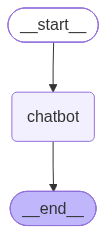

In [6]:
from IPython.display import Image, display 

# 그래프 구조를 머메이드 다이어그램 PNG로 그려서 출력 (실패해도 넘어감)
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### 2-6. 실행

질문을 넣고 `invoke()`로 실행하면 `{'answer': ...}`만 돌아온다. 노드는 `messages`도 갱신했지만, `output_schema=OutputState`로 출력을 제한했기 때문에 결과에서는 빠진다. 내부 기록은 그래프 안에만 남기고, 밖으로는 필요한 값만 내보낼 수 있다는 뜻이다.

In [7]:
# 입력은 InputState 형태(question)로 넣고, 출력은 OutputState 형태(answer)로 받는다.
graph.invoke({"question": "대한민국의 수도는 어디인가요?"})

{'answer': '대한민국의 수도는 서울입니다.'}

## 3. 조건이 추가된 그래프 (가드레일)

질문이 너무 짧으면 LLM을 부르지 않고 바로 끝내는 그래프를 만든다. LLM 호출 전에 입력을 검사하는 이런 노드를 **가드레일(guardrail)**이라고 한다.

### 3-1. 상태 정의

이번에는 상태를 하나만 쓴다. 대화 기록 `messages`와, 가드레일이 계산한 질문 길이 `question_length`를 담는다.

In [19]:
from typing import TypedDict, Annotated 
from operator import add 

# messages: 대화 기록(add 리듀서로 누적), question_length: 가드레일이 계산한 질문 길이
class State(TypedDict):
    messages: Annotated[list[str], add]
    question_length: int 

### 3-2. 그래프 생성

`input_schema`/`output_schema`를 따로 주지 않았으므로 입력·출력 모두 `State` 전체가 된다.

In [20]:
from langgraph.graph import StateGraph 

# 입력·출력 스키마를 따로 주지 않으면 State 전체를 받고 State 전체를 돌려준다.
graph_builder = StateGraph(State)

### 3-3. 가드레일 노드

마지막 메시지(사용자 질문)의 글자 수를 세서 `question_length`에 저장한다. 한글도 한 글자를 1로 센다.

In [21]:
# 가드레일 노드: LLM을 부르기 전에 질문 길이를 계산해 둔다.
def guardrail(state: State) -> State:
    # 마지막 메시지(방금 들어온 질문)의 글자 수
    question_length = len(state["messages"][-1])
    return {
        "question_length": question_length
    }
    
graph_builder.add_node("guardrail", guardrail)

### 3-4. 챗봇 노드

마지막 메시지를 LLM에 보내고 답변만 `messages`로 반환한다. `add` 리듀서 덕분에 질문 뒤에 답변이 이어 붙는다.

In [22]:
from langchain_openai import ChatOpenAI 

llm = ChatOpenAI(model="gpt-4o")

def chatbot(state: State) -> State:
    # 마지막 메시지(질문)를 LLM에 그대로 보낸다.
    question = state["messages"][-1] 
    response = llm.invoke(question) 
    # 답변만 반환 -> add 리듀서로 기존 messages(질문) 뒤에 추가된다.
    return {
        "messages": [response.content]
    }
    
graph_builder.add_node("chatbot", chatbot)

### 3-5. 조건부 엣지

`routing_function`은 `question_length`가 3보다 크면(4글자 이상) `"chatbot"`을, 아니면 `END`를 반환한다. `add_conditional_edges`의 세 번째 인자는 **라우팅 함수의 반환값 → 다음 노드** 매핑이다. `END`도 실제 값은 `"__end__"`라는 문자열이라 매핑의 키로 그대로 쓸 수 있다.

In [23]:
# 라우팅 함수: 상태를 보고 다음에 실행할 노드 이름을 반환한다.
def routing_function(state: State) -> str:
    # 4글자 이상이면 LLM 호출, 3글자 이하면 바로 종료
    if state["question_length"] > 3:
        return "chatbot"
    else:
        return END
    
# guardrail 실행 후 routing_function의 반환값에 따라 다음 노드로 분기
graph_builder.add_conditional_edges(
    "guardrail",
    routing_function,
    # 반환값 -> 다음 노드 매핑
    {"chatbot": "chatbot", END: END}
)

### 3-6. 엣지 연결과 컴파일

시작점을 `guardrail`로 연결하고, `chatbot`이 끝나면 종료한다. `guardrail` 다음은 위의 조건부 엣지가 정한다.

In [24]:
# 시작 -> guardrail (guardrail 다음은 조건부 엣지가 결정)
graph_builder.add_edge(START, "guardrail")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

### 3-7. 그래프 구조 확인

`guardrail`에서 `chatbot`과 `__end__`로 가는 선이 점선으로 그려진다. 점선은 조건부 엣지, 실선은 항상 지나가는 일반 엣지다.

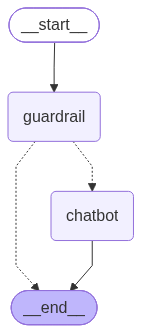

In [25]:
from IPython.display import Image, display 

# 점선 = 조건부 엣지, 실선 = 일반 엣지
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### 3-8. 실행: 짧은 질문은 차단

`"ㅇ"`은 1글자라서 `guardrail` 다음에 바로 `END`로 간다. LLM을 호출하지 않았으므로 `messages`에 답변이 없고, 계산된 `question_length`만 남는다.

In [26]:
# 1글자 -> 가드레일에서 차단 (LLM 호출 없음)
graph.invoke({"messages":["ㅇ"]})

{'messages': ['ㅇ'], 'question_length': 1}

### 3-9. 실행: 4글자 이상은 통과

`"안녕하세요"`는 5글자라서 `chatbot`까지 실행되고, 질문 뒤에 LLM 답변이 추가된다. 출력 스키마를 따로 정하지 않았으므로 `messages`와 `question_length`가 모두 반환된다.

In [27]:
# 5글자 -> chatbot까지 실행되어 답변이 messages에 추가된다.
graph.invoke({"messages":["안녕하세요"]})

{'messages': ['안녕하세요', '안녕하세요! 무엇을 도와드릴까요?'], 'question_length': 5}

## 정리

| 개념 | 코드 | 핵심 |
|---|---|---|
| 입력·출력 스키마 분리 | `StateGraph(OverallState, input_schema=..., output_schema=...)` | 내부에서는 전체 상태를 쓰고, 밖에서 넣고 받는 값만 제한한다 |
| 노드가 받는 상태 | `def chatbot(state: InputState)` | 노드 함수의 타입 힌트에 적은 키만 노드에 전달된다 |
| 리듀서로 기록 누적 | `Annotated[list[str], add]` | 노드는 새 메시지만 반환하고, 누적은 리듀서가 한다 |
| 컴파일·실행 | `graph_builder.compile()` → `graph.invoke({...})` | 설계도를 실행 가능한 그래프로 바꾼 뒤 입력을 넣어 실행 |
| 가드레일 | `guardrail` 노드 + `add_conditional_edges` | LLM 호출 전에 입력을 검사해서 조건에 맞을 때만 다음 노드로 보낸다 |
| 구조 확인 | `graph.get_graph().draw_mermaid_png()` | 점선은 조건부 엣지, 실선은 일반 엣지 |

참고로 가드레일 노드는 `state["messages"][-1]`로 마지막 메시지를 꺼내기 때문에, `messages`를 빈 리스트로 넣으면 `IndexError`가 난다. 실제 서비스라면 빈 입력도 가드레일에서 걸러야 한다.